In [38]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input,Lambda,UpSampling2D,Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,Flatten,BatchNormalization, Activation,ConvLSTM2D,TimeDistributed, GlobalAveragePooling2D, GlobalMaxPooling2D, Add, multiply,Reshape,RepeatVector,LayerNormalization
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
from tensorflow.keras.callbacks         import LearningRateScheduler,Callback

from sklearn.metrics                    import mean_squared_error,r2_score,mean_absolute_error

import sys
import os
import numpy as np
import math
import time
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

In [24]:
directory= os.path.abspath("/home/guiomar/Desktop/CODES/predicting-flow-patterns")
sys.path.append(directory)
from NpyDataGenerator import DataGenerator

### 1. Dataset Creation and Loading

In [25]:
directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
#directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_Masked'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

nbatch = 10

In [26]:
g_train = sorted(glob.glob(os.path.join(gtrain, "*.npy")))
g_test  = sorted(glob.glob(os.path.join(gtest, "*.npy")))
g_val   = sorted(glob.glob(os.path.join(gval, "*.npy")))

p_train = sorted(glob.glob(os.path.join(ptrain, "*.npy")))
p_test  = sorted(glob.glob(os.path.join(ptest, "*.npy")))
p_val   = sorted(glob.glob(os.path.join(pval, "*.npy")))

v_train = sorted(glob.glob(os.path.join(vtrain, "*.npy")))
v_test  = sorted(glob.glob(os.path.join(vtest, "*.npy")))
v_val   = sorted(glob.glob(os.path.join(vval, "*.npy")))

vx_train = sorted(glob.glob(os.path.join(vxtrain, "*.npy")))
vx_test  = sorted(glob.glob(os.path.join(vxtest, "*.npy")))
vx_val   = sorted(glob.glob(os.path.join(vxval, "*.npy")))

vy_train = sorted(glob.glob(os.path.join(vytrain, "*.npy")))
vy_test  = sorted(glob.glob(os.path.join(vytest, "*.npy")))
vy_val   = sorted(glob.glob(os.path.join(vyval, "*.npy")))

In [27]:
train_ds=DataGenerator(g_train,p_train,v_train,vx_train,vy_train)
test_ds=DataGenerator(g_test,p_test,v_test,vx_test,vy_test)
val_ds=DataGenerator(g_val,p_val,v_val,vx_val,vy_val)

### 2. Hyperparameters

In [41]:
num_epochs    =200
patience      =15     # How long to wait after last time validation loss improved
LR            =0.001

# Model name
model_names=['ConvLSTM']
NamesKeras=['Arch_1.keras','Arch_2.keras','Arch_3.keras','Arch_4.keras','Arch_5.keras']
model_name    =model_names[0]
save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
#save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1

number_of_filters = [16,32,64]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
DECAY_RATE=0.04

### 3. Exponential Decay Learning Rate

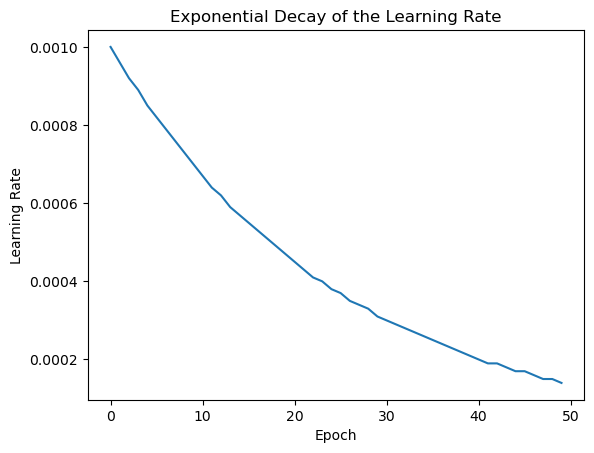

In [29]:
def exponential_decay(epoch,lr_ini=LR,decay_rate=DECAY_RATE,epochs=num_epochs):
    if epoch < epochs*0.001:
        return lr_ini
    else:
        return  lr_ini * np.exp(-decay_rate*epoch)
    
epochs = np.arange(num_epochs)
learning_rates = [round(exponential_decay(epoch),5) for epoch in epochs]


plt.plot(epochs, learning_rates, label="Learning Rate")
plt.title("Exponential Decay of the Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(False)
plt.show()  

### 4. Callbacks

In [30]:
lr_scheduler = LearningRateScheduler(lambda epoch: exponential_decay(epoch), verbose=1)
optimizer = Adam(learning_rate=LR)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',  min_delta=1e-2, patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Test5_Results_weights/Test1_Best_weights.weights.h5'
checkpoint_weight=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)
checkpoint_keras = tf.keras.callbacks.ModelCheckpoint(NamesKeras[0],save_best_only=True)


In [ ]:

#Optional 
def MSEplus(u_true, u_pred):
    
  Eps=1e-4
  
  Ip_value = tf.reduce_sum(tf.cast(u_true != 0.0, tf.float64)) 
  u_true = tf.cast(u_true, dtype=tf.float64)
  u_pred = tf.cast(u_pred, dtype=tf.float64)  
  E_normL2=tf.sqrt(tf.reduce_sum(tf.square(u_true - u_pred)))
  E=tf.reduce_sum(tf.square(u_true - u_pred))
  u_pred_normL2=tf.sqrt(tf.reduce_sum(tf.square(u_pred)))
  mse_loss = tf.reduce_sum(E + E_normL2 / (u_pred_normL2 + Eps))
  mse_loss=mse_loss/Ip_value
 
  return mse_loss 

In [31]:
def conv2DLSTM(x,kernel,state=True):
     x = layers.ConvLSTM2D(filters=kernel, kernel_size=3,
                           padding="same", return_sequences=state)(x)
     x = layers.BatchNormalization()(x)
     return x  

In [44]:


def make_model():
    
    image_input = Input((img_height, img_width, channel))
    reshaped_input = layers.Reshape((1,img_height, img_width, channel))(image_input)

    # Encoder
    x=conv2DLSTM(reshaped_input,number_of_filters[0],True)
    x=conv2DLSTM(x,number_of_filters[1],True)
    x=conv2DLSTM(x,number_of_filters[2],True)

    # Bottleneck
    x=conv2DLSTM(x,number_of_filters[2],True)

    # Decoder
    x=conv2DLSTM(x,number_of_filters[1],True)
    x=conv2DLSTM(x,number_of_filters[0],True)

    flows_out = layers.Conv3D(4, (1, 1,1), activation=f_activation_last,name='flows_output',padding="same")(x)

    
    model = keras.Model(inputs=image_input, outputs=flows_out)
    model.summary()

    model.compile(optimizer=optimizer, 
              loss = ['mean_squared_error'],                     # 'mean_squared_error'
              
              metrics= ['mae', "root_mean_squared_error"] )
    return model


### 5. Architecture

In [45]:
M=make_model()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 1, 64, 256, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_9 (ConvLSTM2D)      │ (None, 1, 64, 256, 16) │         9,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1, 64, 256, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_10 (ConvLSTM2D)     │ (None, 1, 64, 256, 32) │        55,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1, 64, 256, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_11 (ConvLSTM2D)     │ (None, 1, 64, 256, 64) │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 1, 64, 256, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_12 (ConvLSTM2D)     │ (None, 1, 64, 256, 64) │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1, 64, 256, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_13 (ConvLSTM2D)     │ (None, 1, 64, 256, 32) │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 1, 64, 256, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_14 (ConvLSTM2D)     │ (None, 1, 64, 256, 16) │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 1, 64, 256, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flows_output (Conv3D)           │ (None, 1, 64, 256, 4)  │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 721,284 (2.75 MB)

 Trainable params: 720,836 (2.75 MB)

 Non-trainable params: 448 (1.75 KB)

### 6. Parameters Number

In [46]:
params_simple = M.count_params()
print('Parameters Number: ', params_simple)

Parameters Number:  721284


### 7. Fitting

In [51]:
print("Starting training")
start_time_for_fit = time.time()
history = M.fit(train_ds,epochs=num_epochs,validation_data = val_ds,
                callbacks=[lr_scheduler,early_stopping,checkpoint_weight,checkpoint_keras])
end_time_for_fit = time.time()
Training_time = end_time_for_fit - start_time_for_fit
print(f"TRAINING TIME IN  {Training_time:.4f} segundos.")
    

Starting training

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/50
  12/1400 ━━━━━━━━━━━━━━━━━━━━ 26:11 1s/step - loss: 0.0290 - mae: 0.1285 - root_mean_squared_error: 0.1702

KeyboardInterrupt: 

### 8. Evaluation

In [ ]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.4f}")

### 9. Prediction

In [ ]:
xtrue=[]
ytrue=[]
ypred = []
for x,y in test_ds:
    xtrue.append(x.numpy())
    ytrue.append(y.numpy())
 
start_time_pred=time.time()  
for i in range(len(ytrue)):    
    ypred.append(M.predict(xtrue[i]))
end_time_pred=time.time() 

inference_time = end_time_pred - start_time_pred


print(f"PREDICTING TIME IN  {inference_time:.4f} seconds.")

In [ ]:
# Metrics
y_preds = []
y_trues = []

for x_batch, y_batch in test_ds:
    y_pred = M.predict(x_batch)
    y_preds.append(y_pred)
    y_trues.append(y_batch)
    
y_preds = np.concatenate(y_preds, axis=0)  # (N, H, W, 4)
y_trues = np.concatenate(y_trues, axis=0)

# MSE, MAE, RMSE by channel
for i, var in enumerate(["p", "v", "vx", "vy"]):
    mse = mean_squared_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    mae = mean_absolute_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    rmse = np.sqrt(mse)
    print(f"{var}: MSE = {mse:.4f}, MAE = {mae:.4f}, RMSE ={rmse:.4f}")


y_true_flat = y_trues.flatten()
y_pred_flat = y_preds.flatten()

mse = mean_squared_error(y_true_flat, y_pred_flat)
mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mse)
maepercent=mae*100
print(f"MSE global: {mse:.6f}")
print(f"MAE global: {mae:.6f}")
print(f"MAE % global: {maepercent:.6f}")
print(f"RMSE global: {rmse:.6f}")


### 10. Figures

In [ ]:
pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(8, 5))
plt.yscale('log')       # Escala logarítmica para el eje Y
plt.grid(True, which='both')  # Mostrar grid tanto en escala mayor como menor
plt.title("Loss vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss (log)")
plt.tight_layout()
plt.show()

In [ ]:

pd.DataFrame(history.history)[['mae', 'val_mae']].plot(figsize=(8, 5))
plt.yscale('log')       # Escala logarítmica para el eje Y
plt.grid(True, which='both')  # Mostrar grid tanto en escala mayor como menor
plt.title("Mae vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Mae (log)")
plt.tight_layout()
plt.show()

In [ ]:

pd.DataFrame(history.history)[['root_mean_squared_error', 'val_root_mean_squared_error']].plot(figsize=(8, 5))
       # Escala logarítmica para el eje Y
plt.grid(True, which='both')  # Mostrar grid tanto en escala mayor como menor
plt.title("RMSE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel(" RMSE")
plt.tight_layout()
plt.show()

### 11. Qualitative Visualization

In [ ]:
def plotting():
    n = random.randint(0, len(xtrue)-1)
    m = random.randint(0, nbatch-1)
    titles = [ 'P pred', 'P true','V pred', 'V true','Vx pred', 'Vx true','Vy pred', 'Vy true']
    fig, axes = plt.subplots(4, 3, figsize=(16, 10))
    
    error=[]
    for i in range(4):
            error.append(np.abs(ytrue[m][n][:,:,i]- ypred[m][n][:,:,i]))

            axes[i,0].imshow(ypred[m][n][:,:,i], cmap='gray')
            axes[i, 0].set_title(titles[2*i])
            axes[i, 0].axis('off')

            axes[i,1].imshow(ytrue[m][n][:,:,i], cmap='gray')
            axes[i, 1].set_title(titles[2*i+1])
            axes[i, 1].axis('off')

            e=axes[i,2].imshow(error[0], cmap='turbo')
            axes[i, 2].set_title('Absolute Error')
            axes[i, 2].axis('off')
            plt.colorbar(e, ax=axes[i,2], fraction=0.046)

    for ax in axes.flat:
        ax.axis('off')

In [ ]:
plotting()

In [ ]:
plotting()

In [ ]:
plotting()

In [ ]:
plotting()